In [1]:
import pandas as pd

df = pd.read_csv("/content/order_history_kaggle_data.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (21321, 29)

Columns:
['Restaurant ID', 'Restaurant name', 'Subzone', 'City', 'Order ID', 'Order Placed At', 'Order Status', 'Delivery', 'Distance', 'Items in order', 'Instructions', 'Discount construct', 'Bill subtotal', 'Packaging charges', 'Restaurant discount (Promo)', 'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount', 'Brand pack discount', 'Total', 'Rating', 'Review', 'Cancellation / Rejection reason', 'Restaurant compensation (Cancellation)', 'Restaurant penalty (Rejection)', 'KPT duration (minutes)', 'Rider wait time (minutes)', 'Order Ready Marked', 'Customer complaint tag', 'Customer ID']


,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [2]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Convert date/time columns
# -----------------------------

df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')

# -----------------------------
# 2. Basic data quality checks
# -----------------------------

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nOrder Status:")
print(df['Order Status'].value_counts(dropna=False))

# -----------------------------
# 3. Create time features
# -----------------------------

df['Order Date'] = df['Order Placed At'].dt.date
df['Order Month'] = df['Order Placed At'].dt.to_period('M').astype(str)
df['Order Day'] = df['Order Placed At'].dt.day_name()
df['Order Hour'] = df['Order Placed At'].dt.hour

# -----------------------------
# 4. Customer-level order count
# -----------------------------

customer_orders = (
    df.groupby('Customer ID')['Order ID']
      .nunique()
      .reset_index(name='Order Count')
)

# -----------------------------
# 5. Define customer type
# -----------------------------

customer_orders['Customer Type'] = np.where(
    customer_orders['Order Count'] == 1,
    'One-time Customer',
    'Repeat Customer'
)

# -----------------------------
# 6. Merge back to order data
# -----------------------------

df = df.merge(
    customer_orders[['Customer ID', 'Order Count', 'Customer Type']],
    on='Customer ID',
    how='left'
)

print("\nCustomer Type:")
print(df[['Customer ID', 'Order Count', 'Customer Type']].drop_duplicates()
      ['Customer Type'].value_counts())

print("\nFinal shape:", df.shape)

df.head()

/tmp/ipykernel_459/186546264.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')


Shape: (21321, 29)

Missing values:
Restaurant penalty (Rejection)            21318
Restaurant compensation (Cancellation)    21188
Cancellation / Rejection reason           21135
Review                                    21025
Customer complaint tag                    20852
Instructions                              20601
Rating                                    18830
Discount construct                         5498
KPT duration (minutes)                      295
Rider wait time (minutes)                   168
Subzone                                       0
Restaurant name                               0
Restaurant ID                                 0
Bill subtotal                                 0
Items in order                                0
dtype: int64

Duplicate rows: 0

Order Status:
Order Status
Delivered           21131
Rejected              158
Returned               25
Return cancelled        3
Picked up               3
Timed out               1
Name: count, dtype: int64

C

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID,Order Date,Order Month,Order Day,Order Hour,Order Count,Customer Type
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,2024-09-10,2024-09,Tuesday,23,2,Repeat Customer
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,2024-09-10,2024-09,Tuesday,23,12,Repeat Customer
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,2024-09-10,2024-09,Tuesday,15,7,Repeat Customer
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,2024-09-10,2024-09,Tuesday,15,4,Repeat Customer
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,2024-09-10,2024-09,Tuesday,15,14,Repeat Customer


Core Retention Metrics

In [3]:
# Convert important numeric columns to numeric
numeric_cols = [
    'Total',
    'Rating',
    'Distance',
    'KPT duration (minutes)',
    'Rider wait time (minutes)'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[numeric_cols].dtypes)

Total                        float64
Rating                       float64
Distance                     float64
KPT duration (minutes)       float64
Rider wait time (minutes)    float64
dtype: object


In [4]:
# -----------------------------
# Core Customer Retention Metrics
# -----------------------------

customer_summary = (
    df.groupby('Customer ID')
      .agg(
          total_orders=('Order ID', 'nunique'),
          total_spend=('Total', 'sum'),
          avg_order_value=('Total', 'mean'),
          avg_rating=('Rating', 'mean'),
          avg_distance=('Distance', 'mean'),
          avg_kpt=('KPT duration (minutes)', 'mean'),
          avg_rider_wait=('Rider wait time (minutes)', 'mean')
      )
      .reset_index()
)

# Customer segments
customer_summary['Customer Type'] = np.where(
    customer_summary['total_orders'] == 1,
    'One-time Customer',
    'Repeat Customer'
)

# Overall metrics
total_customers = customer_summary['Customer ID'].nunique()
repeat_customers = (
    customer_summary['Customer Type'] == 'Repeat Customer'
).sum()

repeat_rate = repeat_customers / total_customers * 100

avg_orders = customer_summary['total_orders'].mean()
avg_order_value = df['Total'].mean()

print("Total Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_rate, 2), "%")
print("Average Orders per Customer:", round(avg_orders, 2))
print("Average Order Value:", round(avg_order_value, 2))

print("\nCustomer Summary:")
print(
    customer_summary.groupby('Customer Type')
    [['total_orders', 'total_spend', 'avg_order_value',
      'avg_rating', 'avg_distance', 'avg_kpt', 'avg_rider_wait']]
    .mean()
    .round(2)
)

Total Customers: 11607
Repeat Customers: 3894
Repeat Customer Rate: 33.55 %
Average Orders per Customer: 1.84
Average Order Value: 682.62

Customer Summary:
                   total_orders  total_spend  avg_order_value  avg_rating  \
Customer Type                                                               
One-time Customer          1.00       698.87           698.87        4.03   
Repeat Customer            3.49      2353.29           689.64        4.46   

                   avg_distance  avg_kpt  avg_rider_wait  
Customer Type                                             
One-time Customer           NaN    17.47            4.86  
Repeat Customer             NaN    17.35            4.84  


Finding the retention drivers

In [5]:
# Convert these columns to numeric
cols_to_convert = [
    'Discount construct',
    'Items in order',
    'Bill subtotal',
    'Total',
    'Rating',
    'KPT duration (minutes)',
    'Rider wait time (minutes)'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check datatypes
print(df[cols_to_convert].dtypes)

Discount construct           float64
Items in order               float64
Bill subtotal                float64
Total                        float64
Rating                       float64
KPT duration (minutes)       float64
Rider wait time (minutes)    float64
dtype: object


In [ ]:
# Retention driver comparison

for col in cols_to_convert:
    print("\n", col)
    print(
        df.groupby('Customer Type')[col]
          .mean()
          .round(2)
    )


 Discount construct
Customer Type
One-time Customer   NaN
Repeat Customer     NaN
Name: Discount construct, dtype: float64

 Items in order
Customer Type
One-time Customer   NaN
Repeat Customer     NaN
Name: Items in order, dtype: float64

 Bill subtotal
Customer Type
One-time Customer    767.52
Repeat Customer      740.19
Name: Bill subtotal, dtype: float64

 Total
Customer Type
One-time Customer    698.87
Repeat Customer      673.41
Name: Total, dtype: float64

 Rating
Customer Type
One-time Customer    4.03
Repeat Customer      4.54
Name: Rating, dtype: float64

 KPT duration (minutes)
Customer Type
One-time Customer    17.47
Repeat Customer      17.25
Name: KPT duration (minutes), dtype: float64

 Rider wait time (minutes)
Customer Type
One-time Customer    4.86
Repeat Customer      4.80
Name: Rider wait time (minutes), dtype: float64


Key product insight so far

Repeat customers have substantially higher ratings (4.54 vs 4.03), while operational metrics such as KPT and rider wait are nearly identical.

Rating and complaint analysis

In [6]:
# Rating distribution by customer type

rating_analysis = (
    df.groupby('Customer Type')['Rating']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print("Rating Distribution (%):")
print(rating_analysis)


# Complaint analysis

complaint_analysis = (
    df.groupby('Customer Type')['Customer complaint tag']
      .apply(lambda x: x.notna().sum())
)

print("\nCustomers/Orders with Complaint Tags:")
print(complaint_analysis)


# Cancellation / rejection analysis

status_analysis = (
    df.groupby('Customer Type')['Order Status']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print("\nOrder Status Distribution (%):")
print(status_analysis)

Rating Distribution (%):
Customer Type      Rating
One-time Customer  5.0       58.29
                   4.0       15.78
                   1.0       11.95
                   3.0        8.12
                   2.0        5.86
Repeat Customer    5.0       75.50
                   4.0       13.72
                   3.0        4.49
                   1.0        4.43
                   2.0        1.87
Name: proportion, dtype: float64

Customers/Orders with Complaint Tags:
Customer Type
One-time Customer    197
Repeat Customer      272
Name: Customer complaint tag, dtype: int64

Order Status Distribution (%):
Customer Type      Order Status    
One-time Customer  Delivered           99.20
                   Rejected             0.67
                   Returned             0.13
Repeat Customer    Delivered           99.06
                   Rejected             0.78
                   Returned             0.11
                   Picked up            0.02
                   Return cancelled  

In [7]:
# Complaint rate by customer type

complaint_rate = (
    df.groupby('Customer Type')['Customer complaint tag']
      .apply(lambda x: x.notna().mean() * 100)
      .round(2)
)

print("Complaint Rate (%):")
print(complaint_rate)

Complaint Rate (%):
Customer Type
One-time Customer    2.55
Repeat Customer      2.00
Name: Customer complaint tag, dtype: float64


In [8]:
print("\nComplaint Categories:")
print(
    df['Customer complaint tag']
      .value_counts(dropna=True)
      .head(20)
)


Complaint Categories:
Customer complaint tag
Non-refunded complaint              157
Poor taste or quality               120
Poor packaging or spillage          104
Wrong item(s) delivered              48
Item(s) missing or not delivered     40
Name: count, dtype: int64


Product insight

The strongest story we're getting is:

Customer satisfaction appears to be more closely associated with repeat ordering than operational speed.

Why?

Rating: 4.54 repeat vs 4.03 one-time → noticeable difference
Complaint rate: 2.00% repeat vs 2.55% one-time
KPT: 17.25 vs 17.47 min → almost identical
Rider wait: 4.80 vs 4.86 min → almost identical
Delivery success: 99.06% vs 99.20% → almost identical

So our eventual recommendation could focus on improving food quality, packaging, order accuracy and refund experience, rather than simply trying to make preparation/rider wait times faster.

Cohort Retention Analysis

In [9]:
# Sort orders chronologically
df = df.sort_values(['Customer ID', 'Order Placed At'])

# First order date for every customer
first_order = (
    df.groupby('Customer ID')['Order Placed At']
      .min()
      .reset_index(name='First Order Date')
)

# Merge first order date
df = df.merge(first_order, on='Customer ID', how='left')

# First-order month
df['Cohort Month'] = (
    df['First Order Date']
      .dt.to_period('M')
      .astype(str)
)

# Order month
df['Order Month'] = (
    df['Order Placed At']
      .dt.to_period('M')
      .astype(str)
)

# Customer-month activity
cohort_data = (
    df.groupby(['Cohort Month', 'Order Month'])['Customer ID']
      .nunique()
      .reset_index(name='Active Customers')
)

print(cohort_data.head(20))

   Cohort Month Order Month  Active Customers
0       2024-09     2024-09              3205
1       2024-09     2024-10               820
2       2024-09     2024-11               678
3       2024-09     2024-12               616
4       2024-09     2025-01               510
5       2024-10     2024-10              2520
6       2024-10     2024-11               471
7       2024-10     2024-12               355
8       2024-10     2025-01               302
9       2024-11     2024-11              2233
10      2024-11     2024-12               355
11      2024-11     2025-01               269
12      2024-12     2024-12              2018
13      2024-12     2025-01               310
14      2025-01     2025-01              1631


In [10]:
# Create cohort retention table

cohort_pivot = cohort_data.pivot(
    index='Cohort Month',
    columns='Order Month',
    values='Active Customers'
)

# Calculate retention relative to the cohort's first month
retention_table = cohort_pivot.div(
    cohort_pivot.iloc[:, 0],
    axis=0
) * 100

retention_table = retention_table.round(2)

print("Cohort Retention (%):")
print(retention_table)

Cohort Retention (%):
Order Month   2024-09  2024-10  2024-11  2024-12  2025-01
Cohort Month                                             
2024-09         100.0    25.59    21.15    19.22    15.91
2024-10           NaN      NaN      NaN      NaN      NaN
2024-11           NaN      NaN      NaN      NaN      NaN
2024-12           NaN      NaN      NaN      NaN      NaN
2025-01           NaN      NaN      NaN      NaN      NaN


Correct retention calculation

In [11]:
# Create cohort activity matrix
cohort_pivot = cohort_data.pivot(
    index='Cohort Month',
    columns='Order Month',
    values='Active Customers'
)

# Calculate retention using each cohort's own first month
retention_table = cohort_pivot.copy()

for cohort in retention_table.index:
    cohort_size = cohort_pivot.loc[cohort, cohort]
    retention_table.loc[cohort] = (
        cohort_pivot.loc[cohort] / cohort_size * 100
    )

retention_table = retention_table.round(2)

print("Correct Cohort Retention (%):")
print(retention_table)

Correct Cohort Retention (%):
Order Month   2024-09  2024-10  2024-11  2024-12  2025-01
Cohort Month                                             
2024-09         100.0    25.59    21.15    19.22    15.91
2024-10           NaN   100.00    18.69    14.09    11.98
2024-11           NaN      NaN   100.00    15.90    12.05
2024-12           NaN      NaN      NaN   100.00    15.36
2025-01           NaN      NaN      NaN      NaN   100.00


The largest retention challenge occurs immediately after the first order. Only about 15–26% of customers return in the following month, depending on cohort.

Analyze the first-order experience

In [12]:
# Keep only each customer's first order
first_orders = (
    df.sort_values('Order Placed At')
      .groupby('Customer ID')
      .first()
      .reset_index()
)

# Check first-order experience by customer type
first_order_analysis = (
    first_orders.groupby('Customer Type')
    [['Rating',
      'KPT duration (minutes)',
      'Rider wait time (minutes)',
      'Bill subtotal',
      'Total']]
    .mean()
    .round(2)
)

print(first_order_analysis)

                   Rating  KPT duration (minutes)  Rider wait time (minutes)  \
Customer Type                                                                  
One-time Customer    4.03                   17.47                       4.86   
Repeat Customer      4.49                   17.49                       5.03   

                   Bill subtotal   Total  
Customer Type                             
One-time Customer         767.52  698.87  
Repeat Customer           744.76  674.17  


🔥 Main insight

Rating is the standout variable.

Customers who eventually become repeat customers gave their first order an average rating of 4.49, compared with 4.03 for customers who never returned.

Meanwhile:

KPT is essentially identical.
Rider wait is only slightly higher for repeat customers.
Order value is slightly lower for repeat customers.

So our product hypothesis becomes:

The quality of the first-order experience appears to be a stronger retention signal than delivery preparation or rider wait time.

Let's quantify the rating effect

In [13]:
# First-order rating vs future retention

rating_retention = (
    first_orders
    .groupby('Rating')
    .agg(
        customers=('Customer ID', 'nunique'),
        repeat_customers=('Customer Type',
                          lambda x: (x == 'Repeat Customer').sum())
    )
    .reset_index()
)

rating_retention['repeat_rate'] = (
    rating_retention['repeat_customers']
    / rating_retention['customers']
    * 100
)

rating_retention = rating_retention.round(2)

print(rating_retention)

   Rating  customers  repeat_customers  repeat_rate
0     1.0        163                57        34.97
1     2.0         70                18        25.71
2     3.0        109                37        33.94
3     4.0        275               135        49.09
4     5.0       1229               712        57.93


In [14]:
# First-order rating vs future retention

rating_retention = (
    first_orders
    .groupby('Rating')
    .agg(
        customers=('Customer ID', 'nunique'),
        repeat_customers=('Customer Type',
                          lambda x: (x == 'Repeat Customer').sum())
    )
    .reset_index()
)

rating_retention['repeat_rate'] = (
    rating_retention['repeat_customers']
    / rating_retention['customers']
    * 100
)

rating_retention = rating_retention.round(2)

print(rating_retention)

   Rating  customers  repeat_customers  repeat_rate
0     1.0        163                57        34.97
1     2.0         70                18        25.71
2     3.0        109                37        33.94
3     4.0        275               135        49.09
4     5.0       1229               712        57.93


There's a clear positive relationship between first-order satisfaction and future repeat behaviour, especially from 3★ → 4★ → 5★.

2★: only 25.71% returned
4★: 49.09% returned
5★: 57.93% returned

So a strong Product Analyst conclusion is:

First-order customer satisfaction is a strong retention signal. Customers giving 4–5★ on their first order show substantially higher repeat-order rates than lower-rated customers.

In [17]:
restaurant_customers = (
    df[['Restaurant name', 'Customer ID', 'Customer Type']]
    .drop_duplicates()
)

restaurant_retention = (
    restaurant_customers
    .groupby('Restaurant name')
    .agg(
        customers=('Customer ID', 'nunique'),
        repeat_customers=('Customer Type',
                          lambda x: (x == 'Repeat Customer').sum())
    )
    .reset_index()
)

restaurant_retention['repeat_rate'] = (
    restaurant_retention['repeat_customers']
    / restaurant_retention['customers']
    * 100
)

restaurant_retention = restaurant_retention.sort_values(
    'repeat_rate', ascending=False
)

print(restaurant_retention.round(2))

        Restaurant name  customers  repeat_customers  repeat_rate
2       Masala Junction         27                22        81.48
5  The Chicken Junction         31                21        67.74
3                 Swaad       3268              1315        40.24
1     Dilli Burger Adda        165                66        40.00
4     Tandoori Junction        109                42        38.53
0           Aura Pizzas       8442              2863        33.91



Strong insight

Aura Pizzas accounts for the largest customer base but has a lower repeat rate (33.91%) compared with Swaad (40.24%).

This suggests that product/restaurant-specific experiences may influence retention


Cohort Retention Heatmap.

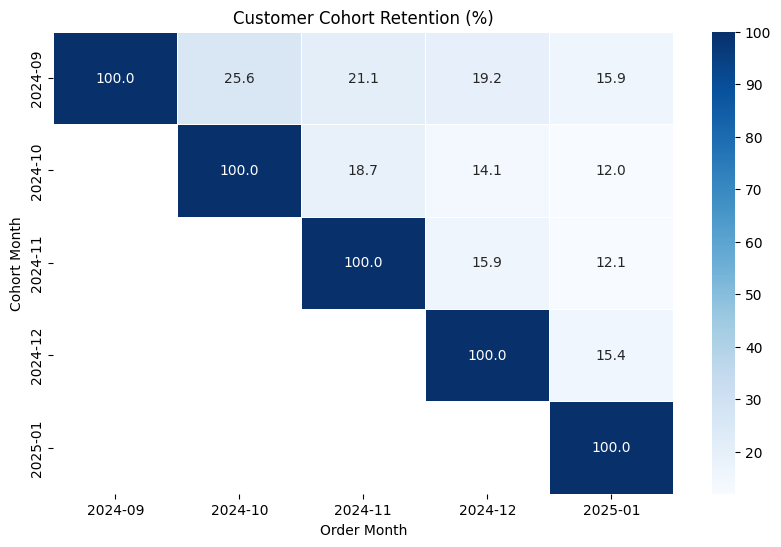

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    retention_table,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Customer Cohort Retention (%)")
plt.xlabel("Order Month")
plt.ylabel("Cohort Month")

plt.show()

Understanding the customer lifecycle

In [19]:
# Customer order frequency distribution

order_frequency = (
    customer_summary['total_orders']
    .value_counts()
    .sort_index()
    .reset_index()
)

order_frequency.columns = ['Orders per Customer', 'Customers']

print(order_frequency)

print("\nPercentage distribution:")

order_frequency['Percentage'] = (
    order_frequency['Customers']
    / order_frequency['Customers'].sum()
    * 100
).round(2)

print(order_frequency)

    Orders per Customer  Customers
0                     1       7713
1                     2       1906
2                     3        824
3                     4        435
4                     5        254
5                     6        134
6                     7        106
7                     8         59
8                     9         48
9                    10         33
10                   11         22
11                   12         19
12                   13          8
13                   14          5
14                   15          8
15                   16          3
16                   17          2
17                   18          3
18                   19          4
19                   20          4
20                   21          5
21                   22          1
22                   23          1
23                   24          1
24                   28          2
25                   29          3
26                   31          2
27                  

Our earlier 33.55% repeat-customer rate means customers who ordered at least twice. But this new distribution shows that:

66.45% never placed a second order.

16.42% placed exactly two orders.

Only 17.13% placed three or more orders.

So the business problem is not simply "How do we get customers to return?"

It is:

How do we convert first-time customers into second-order customers, and then develop those repeat customers into loyal users?

That gives us two separate product opportunities:

First-to-second-order conversion — activation/retention.

Second-to-third-order conversion — habit formation and loyalty.

Measuring the customer value distribution

In [20]:
# Revenue contribution by customer lifecycle stage

lifecycle_value = (
    customer_summary
    .groupby('total_orders')
    .agg(
        customers=('Customer ID', 'nunique'),
        total_revenue=('total_spend', 'sum'),
        avg_customer_spend=('total_spend', 'mean'),
        avg_order_value=('avg_order_value', 'mean')
    )
    .reset_index()
)

lifecycle_value['customer_share'] = (
    lifecycle_value['customers']
    / lifecycle_value['customers'].sum()
    * 100
)

lifecycle_value['revenue_share'] = (
    lifecycle_value['total_revenue']
    / lifecycle_value['total_revenue'].sum()
    * 100
)

lifecycle_value = lifecycle_value.round(2)

print(lifecycle_value)

    total_orders  customers  total_revenue  avg_customer_spend  \
0              1       7713     5390359.66              698.87   
1              2       1906     2658369.92             1394.74   
2              3        824     1767591.97             2145.14   
3              4        435     1179106.36             2710.59   
4              5        254      863525.40             3399.71   
5              6        134      499126.33             3724.82   
6              7        106      476562.38             4495.87   
7              8         59      290056.87             4916.22   
8              9         48      264306.96             5506.40   
9             10         33      240044.93             7274.09   
10            11         22      149960.81             6816.40   
11            12         19      149733.06             7880.69   
12            13          8       92082.84            11510.36   
13            14          5       26424.62             5284.92   
14        

The largest revenue opportunity is not only acquiring new customers, but converting one-time customers into repeat customers and encouraging repeat customers to develop ordering habits.

You can divide the lifecycle into three actionable stages:

One-time customers — activation problem Encourage the second order through personalized recommendations, post-order engagement, and relevant offers.

Two-order customers — habit-formation problem Encourage the third order through reorder reminders, favorite-restaurant suggestions, and convenient repeat ordering.

4+ order customers — loyalty problem Retain high-frequency customers through loyalty benefits, personalized experiences, and proactive service recovery

Time to Second Order

In [23]:
print(df['Order Placed At'].dtype)
print(df['Order Placed At'].head())
print(df['Order Placed At'].isna().sum())
print(df['Customer ID'].nunique())

datetime64[ns]
0   2024-09-03 21:41:00
1   2024-09-26 22:01:00
2   2024-10-01 21:32:00
3   2024-09-08 17:43:00
4   2025-01-10 01:38:00
Name: Order Placed At, dtype: datetime64[ns]
0
11607


In [24]:
order_counts = df.groupby('Customer ID').size()

print(order_counts.value_counts().sort_index().head(10))
print("Customers with 2+ rows:", (order_counts >= 2).sum())

1     7713
2     1906
3      824
4      435
5      254
6      134
7      106
8       59
9       48
10      33
Name: count, dtype: int64
Customers with 2+ rows: 3894


In [25]:
# Sort orders chronologically for each customer
customer_orders = df.sort_values(
    ['Customer ID', 'Order Placed At']
).copy()

# Assign chronological order number
customer_orders['order_number'] = (
    customer_orders.groupby('Customer ID').cumcount() + 1
)

# Get first order date
first_orders = (
    customer_orders[customer_orders['order_number'] == 1]
    [['Customer ID', 'Order Placed At']]
    .rename(columns={'Order Placed At': 'first_order_date'})
)

# Get second order date
second_orders = (
    customer_orders[customer_orders['order_number'] == 2]
    [['Customer ID', 'Order Placed At']]
    .rename(columns={'Order Placed At': 'second_order_date'})
)

# Match customers with both first and second orders
time_to_second = first_orders.merge(
    second_orders,
    on='Customer ID',
    how='inner'
)

# Calculate days between orders
time_to_second['days_to_second_order'] = (
    time_to_second['second_order_date']
    - time_to_second['first_order_date']
).dt.total_seconds() / 86400

# Summary
print("Number of repeat customers:", len(time_to_second))
print(
    "Average days to second order:",
    time_to_second['days_to_second_order'].mean()
)
print(
    "Median days to second order:",
    time_to_second['days_to_second_order'].median()
)
print(
    "Minimum days:",
    time_to_second['days_to_second_order'].min()
)
print(
    "Maximum days:",
    time_to_second['days_to_second_order'].max()
)

print("\nDetailed summary:")
print(time_to_second['days_to_second_order'].describe())

Number of repeat customers: 3894
Average days to second order: 27.9520669263254
Median days to second order: 17.229861111111113
Minimum days: 0.0006944444444444445
Maximum days: 145.8215277777778

Detailed summary:
count    3894.000000
mean       27.952067
std        28.816455
min         0.000694
25%         6.219792
50%        17.229861
75%        41.028299
max       145.821528
Name: days_to_second_order, dtype: float64


Business interpretation: The typical repeat customer returns in about 17 days, so the platform should investigate the period immediately after the first order rather than waiting until the end of the month.

This does not mean that 17 days is the ideal reminder time. It is an observed interval, not an experimentally proven optimal intervention time.

Calculate reorder timing buckets

In [26]:
# Reorder timing buckets

time_to_second['days_to_second_order'] = (
    time_to_second['days_to_second_order'].round(2)
)

total_repeat_customers = len(time_to_second)

timing_summary = pd.DataFrame({
    'Time window': [
        'Within 7 days',
        'Within 14 days',
        'Within 30 days',
        'Within 60 days',
        'More than 60 days'
    ],
    'Customers': [
        (time_to_second['days_to_second_order'] <= 7).sum(),
        (time_to_second['days_to_second_order'] <= 14).sum(),
        (time_to_second['days_to_second_order'] <= 30).sum(),
        (time_to_second['days_to_second_order'] <= 60).sum(),
        (time_to_second['days_to_second_order'] > 60).sum()
    ]
})

timing_summary['Percentage'] = (
    timing_summary['Customers']
    / total_repeat_customers
    * 100
).round(2)

print(timing_summary)

         Time window  Customers  Percentage
0      Within 7 days       1053       27.04
1     Within 14 days       1723       44.25
2     Within 30 days       2592       66.56
3     Within 60 days       3325       85.39
4  More than 60 days        569       14.61


Product recommendation

Use a staged second-order retention journey: engage customers during the first 14 days, evaluate non-reorderers around 30 days, and launch a reactivation strategy for customers who remain inactive after 60 days.

reorder interval

In [27]:
# Calculate the interval between consecutive orders

customer_orders = df.sort_values(
    ['Customer ID', 'Order Placed At']
).copy()

customer_orders['previous_order_date'] = (
    customer_orders.groupby('Customer ID')['Order Placed At']
    .shift(1)
)

customer_orders['days_since_previous_order'] = (
    customer_orders['Order Placed At']
    - customer_orders['previous_order_date']
).dt.total_seconds() / 86400

# Keep only repeat-order intervals
reorder_intervals = customer_orders[
    customer_orders['days_since_previous_order'].notna()
].copy()

print("Number of reorder intervals:", len(reorder_intervals))

print(
    reorder_intervals['days_since_previous_order']
    .describe()
)

Number of reorder intervals: 9714
count    9714.000000
mean       22.102877
std        24.462379
min         0.000000
25%         4.939063
50%        13.009028
75%        30.479167
max       145.821528
Name: days_since_previous_order, dtype: float64


Product insight

Repeat ordering is concentrated around a two-week interval, while a smaller group returns after much longer gaps.

This suggests two possible retention opportunities:

Habit formation: Encourage customers to reorder around their usual ordering interval.

Reactivation: Identify customers whose next order is delayed substantially beyond their previous pattern.

Calculate reorder-interval buckets

In [28]:
# Reorder interval distribution

interval_summary = pd.DataFrame({
    'Reorder interval': [
        'Same day',
        '1–7 days',
        '8–14 days',
        '15–30 days',
        '31–60 days',
        'More than 60 days'
    ],
    'Intervals': [
        (reorder_intervals['days_since_previous_order'] == 0).sum(),
        (
            (reorder_intervals['days_since_previous_order'] > 0) &
            (reorder_intervals['days_since_previous_order'] <= 7)
        ).sum(),
        (
            (reorder_intervals['days_since_previous_order'] > 7) &
            (reorder_intervals['days_since_previous_order'] <= 14)
        ).sum(),
        (
            (reorder_intervals['days_since_previous_order'] > 14) &
            (reorder_intervals['days_since_previous_order'] <= 30)
        ).sum(),
        (
            (reorder_intervals['days_since_previous_order'] > 30) &
            (reorder_intervals['days_since_previous_order'] <= 60)
        ).sum(),
        (reorder_intervals['days_since_previous_order'] > 60).sum()
    ]
})

interval_summary['Percentage'] = (
    interval_summary['Intervals']
    / interval_summary['Intervals'].sum()
    * 100
).round(2)

print(interval_summary)

    Reorder interval  Intervals  Percentage
0           Same day          2        0.02
1           1–7 days       3256       33.52
2          8–14 days       1823       18.77
3         15–30 days       2167       22.31
4         31–60 days       1601       16.48
5  More than 60 days        865        8.90


Product recommendation

Build a personalized reorder journey around the customer’s previous ordering behavior: early engagement during the first week, a second intervention around the second week, and reactivation messaging for customers whose next order is delayed beyond their usual interval.

inspect discount data

In [29]:
discount_cols = [
    'Discount construct',
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]

for col in discount_cols:
    print("\n", col)
    print(df[col].head(10))
    print("Data type:", df[col].dtype)
    print("Unique values:", df[col].nunique())


 Discount construct
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Discount construct, dtype: float64
Data type: float64
Unique values: 0

 Restaurant discount (Promo)
0     99.00
1     99.00
2     99.00
3      0.00
4    198.05
5    270.00
6    100.00
7     78.98
8     78.98
9    157.00
Name: Restaurant discount (Promo), dtype: float64
Data type: float64
Unique values: 700

 Restaurant discount (Flat offs, Freebies & others)
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Restaurant discount (Flat offs, Freebies & others), dtype: float64
Data type: float64
Unique values: 318

 Gold discount
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Gold discount, dtype: float64
Data type: float64
Unique values: 29

 Brand pack discount
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Brand pack discount, dtype: float

In [30]:
discount_columns = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]

# Replace missing discount values with zero
df[discount_columns] = df[discount_columns].fillna(0)

# Calculate total discount
df['total_discount'] = df[discount_columns].sum(axis=1)

# Create a discount indicator
df['used_discount'] = (
    df['total_discount'] > 0
).astype(int)

# Inspect the result
print(df[['total_discount', 'used_discount']].describe())

print("\nDiscount usage:")
print(df['used_discount'].value_counts())

print("\nPercentage using discounts:")
print(
    df['used_discount'].value_counts(normalize=True)
    .mul(100)
    .round(2)
)

       total_discount  used_discount
count    21321.000000   21321.000000
mean       100.025326       0.611088
std        145.885555       0.487515
min          0.000000       0.000000
25%          0.000000       0.000000
50%         90.000000       1.000000
75%        120.000000       1.000000
max       7787.000000       1.000000

Discount usage:
used_discount
1    13029
0     8292
Name: count, dtype: int64

Percentage using discounts:
used_discount
1    61.11
0    38.89
Name: proportion, dtype: float64


iscount analysis shows that discounts are common:

61.11% of orders used at least one discount.

38.89% of orders used no discount.

The median total discount is ₹90.

The average is ₹100.03, but the maximum is ₹7,787, so a few unusually large discounts may be pulling the average upward.

This tells us that discounting is an important part of the platform’s ordering behavior. It does not yet tell us whether discounts improve retention.

First-order discount usage vs repeat behavior

In [31]:
# Sort complete rows chronologically
customer_orders = df.sort_values(
    ['Customer ID', 'Order Placed At']
).copy()

# Take the actual first order row of each customer
first_order = (
    customer_orders
    .drop_duplicates('Customer ID', keep='first')
    .copy()
)

# Total number of orders per customer
order_counts = (
    df.groupby('Customer ID')
    .size()
    .rename('total_orders')
)

# Add order count to first-order data
first_order = first_order.merge(
    order_counts,
    on='Customer ID',
    how='left'
)

# Whether the customer eventually repeated
first_order['repeat_customer'] = (
    first_order['total_orders'] >= 2
).astype(int)

# Whether the first order used a discount
first_order['used_first_order_discount'] = (
    first_order['total_discount'] > 0
).astype(int)

# Summary by first-order discount usage
discount_retention = (
    first_order
    .groupby('used_first_order_discount')
    .agg(
        customers=('Customer ID', 'nunique'),
        repeat_customers=('repeat_customer', 'sum'),
        avg_first_order_discount=('total_discount', 'mean')
    )
    .reset_index()
)

discount_retention['repeat_rate'] = (
    discount_retention['repeat_customers']
    / discount_retention['customers']
    * 100
).round(2)

discount_retention['avg_first_order_discount'] = (
    discount_retention['avg_first_order_discount']
    .round(2)
)

print(discount_retention)

   used_first_order_discount  customers  repeat_customers  \
0                          0       4296              1389   
1                          1       7311              2505   

   avg_first_order_discount  repeat_rate  
0                      0.00        32.33  
1                    162.33        34.26  


First-order discounts may help encourage repeat ordering, but the observed effect is modest. Retention should not depend only on discounts; product experience, food quality, and customer satisfaction may be more important long-term levers.

statistical test

In [32]:
from scipy.stats import chi2_contingency

# Contingency table
contingency_table = pd.crosstab(
    first_order['used_first_order_discount'],
    first_order['repeat_customer']
)

print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("The difference is statistically significant.")
else:
    print("The difference is not statistically significant.")

repeat_customer               0     1
used_first_order_discount            
0                          2907  1389
1                          4806  2505
Chi-square statistic: 4.4399
P-value: 0.035109
The difference is statistically significant.


A reasonable next step is to test targeted first-order incentives, rather than giving discounts to everyone.

For example:

Compare a discount group with a non-discount group.

Measure second-order conversion.

Also track discount cost, revenue, and contribution margin.

Check whether the additional repeat orders justify the discount expense.

README-ready insight

First-order discount usage was associated with a statistically significant but modest increase in repeat rate: 34.26% for discounted first orders versus 32.33% for non-discounted first orders (chi-square test, p = 0.0351). Since the analysis is observational, the result indicates association rather than causation and motivates a controlled experiment on targeted retention incentives.

Complaints vs repeat behavior

In [33]:
# First-order complaint vs repeat behavior

# Sort complete orders chronologically
customer_orders = df.sort_values(
    ['Customer ID', 'Order Placed At']
).copy()

# Select the actual first order row
first_order = (
    customer_orders
    .drop_duplicates('Customer ID', keep='first')
    .copy()
)

# Total orders per customer
order_counts = (
    df.groupby('Customer ID')
    .size()
    .rename('total_orders')
)

# Add total order count
first_order = first_order.merge(
    order_counts,
    on='Customer ID',
    how='left'
)

# Whether the customer eventually repeated
first_order['repeat_customer'] = (
    first_order['total_orders'] >= 2
).astype(int)

# Check complaint column
print("Missing complaint values:",
      first_order['Customer complaint tag'].isna().sum())

print("\nComplaint values:")
print(first_order['Customer complaint tag'].value_counts(dropna=False))

Missing complaint values: 11363

Complaint values:
Customer complaint tag
NaN                                 11363
Non-refunded complaint                 87
Poor taste or quality                  69
Poor packaging or spillage             50
Item(s) missing or not delivered       19
Wrong item(s) delivered                19
Name: count, dtype: int64


In [34]:
# Treat non-null complaint values as customers who had a complaint
first_order['had_first_order_complaint'] = (
    first_order['Customer complaint tag'].notna()
).astype(int)

complaint_retention = (
    first_order.groupby('had_first_order_complaint')
    .agg(
        customers=('Customer ID', 'nunique'),
        repeat_customers=('repeat_customer', 'sum')
    )
    .reset_index()
)

complaint_retention['repeat_rate'] = (
    complaint_retention['repeat_customers']
    / complaint_retention['customers']
    * 100
)

complaint_retention

,had_first_order_complaint,customers,repeat_customers,repeat_rate
0,0,11363,3847,33.855496
1,1,244,47,19.262295


Product interpretation

This suggests that poor first-order experience may be associated with weaker retention. Complaints could be an important early warning signal for customer churn.

However, we should not claim that complaints directly caused customers to leave because:

The complaint group is relatively small.

Other factors may influence repeat ordering.

The dataset does not establish causality.

Business recommendation

Create a first-order service recovery journey:

Detect customers who report a complaint.

Send a resolution or apology message.

Provide targeted compensation where appropriate.

Follow up after resolution.

Measure whether their second-order rate improves.

Cancellation/rejection vs repeat ordering

In [35]:
# Create a copy of the first-order dataset
first_order_status = first_order.copy()

# Identify customers whose first order was not delivered
first_order_status['first_order_failed'] = (
    first_order_status['Order Status'] != 'Delivered'
).astype(int)

# Compare repeat rates
status_retention = (
    first_order_status.groupby('first_order_failed')
    .agg(
        customers=('Customer ID', 'nunique'),
        repeat_customers=('repeat_customer', 'sum')
    )
    .reset_index()
)

status_retention['repeat_rate'] = (
    status_retention['repeat_customers']
    / status_retention['customers']
    * 100
)

status_retention

,first_order_failed,customers,repeat_customers,repeat_rate
0,0,11497,3846,33.452205
1,1,110,48,43.636364


In [36]:
print(first_order_status['Order Status'].value_counts())

Order Status
Delivered           11497
Rejected               91
Returned               17
Timed out               1
Return cancelled        1
Name: count, dtype: int64


Product interpretation

A failed first order should still be treated as a service-recovery event, but this dataset does not show a negative retention effect for that group.

Restaurant-level retention

In [37]:
# Calculate customer-level repeat behavior
restaurant_customer = (
    first_order.groupby('Restaurant name')
    .agg(
        first_order_customers=('Customer ID', 'nunique'),
        repeat_customers=('repeat_customer', 'sum')
    )
    .reset_index()
)

restaurant_customer['repeat_rate'] = (
    restaurant_customer['repeat_customers']
    / restaurant_customer['first_order_customers']
    * 100
)

# Keep restaurants with at least 100 first-order customers
restaurant_retention = (
    restaurant_customer[
        restaurant_customer['first_order_customers'] >= 100
    ]
    .sort_values(
        ['repeat_rate', 'first_order_customers'],
        ascending=[False, False]
    )
)

restaurant_retention.head(15)

,Restaurant name,first_order_customers,repeat_customers,repeat_rate
3,Swaad,3081,1128,36.611490
0,Aura Pizzas,8265,2686,32.498488
1,Dilli Burger Adda,133,34,25.563910


In [38]:
restaurant_retention.tail(15)

,Restaurant name,first_order_customers,repeat_customers,repeat_rate
3,Swaad,3081,1128,36.611490
0,Aura Pizzas,8265,2686,32.498488
1,Dilli Burger Adda,133,34,25.563910


Product interpretation

Restaurant-level retention can help identify:

Restaurants that consistently encourage repeat ordering.

Restaurants that may need menu, pricing, quality, or service improvements.

Potential restaurant-specific retention strategies.

However, restaurant performance may also depend on location, cuisine, delivery experience, discounts, and customer mix. Therefore, we should treat these as associations, not proof that a restaurant causes higher retention.

Customer segmentation and churn-risk identification

In [39]:
# Create customer-level order summary
customer_summary = (
    df.groupby('Customer ID')
    .agg(
        total_orders=('Order ID', 'nunique'),
        total_spend=('Total', 'sum'),
        average_order_value=('Total', 'mean'),
        last_order_date=('Order Placed At', 'max')
    )
    .reset_index()
)

# Assign customer segments
def assign_segment(order_count):
    if order_count == 1:
        return 'One-time'
    elif order_count <= 3:
        return 'Occasional'
    elif order_count <= 5:
        return 'Loyal'
    else:
        return 'Highly loyal'

customer_summary['customer_segment'] = (
    customer_summary['total_orders'].apply(assign_segment)
)

# Segment-level analysis
segment_summary = (
    customer_summary.groupby('customer_segment')
    .agg(
        customers=('Customer ID', 'nunique'),
        total_orders=('total_orders', 'sum'),
        total_revenue=('total_spend', 'sum'),
        average_spend=('total_spend', 'mean'),
        average_order_value=('average_order_value', 'mean')
    )
    .reset_index()
)

segment_summary['customer_share'] = (
    segment_summary['customers']
    / segment_summary['customers'].sum()
    * 100
)

segment_summary['revenue_share'] = (
    segment_summary['total_revenue']
    / segment_summary['total_revenue'].sum()
    * 100
)

segment_summary.sort_values('total_revenue', ascending=False)

,customer_segment,customers,total_orders,total_revenue,average_spend,average_order_value,customer_share,revenue_share
3,One-time,7713,7713,5390359.66,698.866804,698.866804,66.451279,37.036815
2,Occasional,2730,6284,4425961.89,1621.231462,702.704133,23.520289,30.410500
0,Highly loyal,475,4314,2695104.83,5673.904905,630.736995,4.092358,18.517892
1,Loyal,689,3010,2042631.76,2964.632453,678.492990,5.936073,14.034792


Product interpretation

The company should not use the same strategy for every segment:

Segment



Recommended strategy




One-time



Improve first-to-second-order conversion




Occasional



Encourage the next order through personalized reminders




Loyal



Introduce loyalty benefits and increase ordering frequency




Highly loyal



Protect retention and provide exclusive rewards

Recency and churn-risk identification
Now we will identify customers who may be inactive or overdue for another order.

We need a reference date. We will use the latest order date in the dataset and calculate how many days have passed since each customer’s last order.

In [40]:
# Reference date: latest order date in the dataset
reference_date = df['Order Placed At'].max()

# Calculate recency
customer_summary['recency_days'] = (
    reference_date - customer_summary['last_order_date']
).dt.total_seconds() / (60 * 60 * 24)

# Create recency segments
def assign_recency_segment(days):
    if days <= 14:
        return 'Active: 0–14 days'
    elif days <= 30:
        return 'Recently inactive: 15–30 days'
    elif days <= 60:
        return 'At risk: 31–60 days'
    else:
        return 'Churn-risk: 60+ days'

customer_summary['recency_segment'] = (
    customer_summary['recency_days'].apply(assign_recency_segment)
)

# Summarize recency segments
recency_summary = (
    customer_summary.groupby('recency_segment')
    .agg(
        customers=('Customer ID', 'nunique'),
        average_orders=('total_orders', 'mean'),
        average_spend=('total_spend', 'mean'),
        average_recency=('recency_days', 'mean')
    )
    .reset_index()
)

recency_summary

,recency_segment,customers,average_orders,average_spend,average_recency
0,Active: 0–14 days,1658,3.123040,2058.110115,6.416503
1,At risk: 31–60 days,2585,1.861896,1312.102708,43.752193
2,Churn-risk: 60+ days,6171,1.361206,909.527401,103.302120
3,Recently inactive: 15–30 days,1193,2.455993,1791.477351,21.270571


Product interpretation

A practical retention strategy could be:

Segment



Suggested action




Active



Encourage habit formation and cross-sell




15–30 days inactive



Send personalized reorder reminders




31–60 days inactive



Offer targeted reactivation incentives




60+ days inactive



Run win-back campaigns, but avoid excessive discounts

Build the churn-risk table

Create risk segments

In [41]:
def assign_churn_risk(row):
    if row['recency_days'] > 60 and row['total_orders'] == 1:
        return 'High risk: One-time and inactive'
    elif row['recency_days'] > 60 and row['total_orders'] >= 2:
        return 'High-value inactive'
    elif row['recency_days'] > 30:
        return 'Medium risk: Inactive'
    else:
        return 'Low risk: Recently active'

customer_summary['churn_risk_segment'] = (
    customer_summary.apply(assign_churn_risk, axis=1)
)

churn_risk_summary = (
    customer_summary.groupby('churn_risk_segment')
    .agg(
        customers=('Customer ID', 'nunique'),
        average_orders=('total_orders', 'mean'),
        average_spend=('total_spend', 'mean'),
        average_recency=('recency_days', 'mean'),
        total_revenue=('total_spend', 'sum')
    )
    .reset_index()
)

churn_risk_summary['customer_share'] = (
    churn_risk_summary['customers']
    / churn_risk_summary['customers'].sum()
    * 100
)

churn_risk_summary['revenue_share'] = (
    churn_risk_summary['total_revenue']
    / churn_risk_summary['total_revenue'].sum()
    * 100
)

churn_risk_summary.sort_values('total_revenue', ascending=False)

,churn_risk_segment,customers,average_orders,average_spend,average_recency,total_revenue,customer_share,revenue_share
2,Low risk: Recently active,2851,2.843914,1946.537724,12.632183,5549579.05,24.562764,38.130802
3,Medium risk: Inactive,2585,1.861896,1312.102708,43.752193,3391785.50,22.271043,23.304741
0,High risk: One-time and inactive,4835,1.000000,673.202147,106.327707,3254932.38,41.655897,22.364432
1,High-value inactive,1336,2.668413,1764.791325,92.352484,2357761.21,11.510296,16.200026


Product recommendations

Priority



Target segment



Recommended action




1



High-value inactive



Personalized win-back campaign based on previous restaurants and order preferences




2



One-time and inactive



First-to-second-order journey with reminders and carefully targeted incentives




3



Medium risk



Reorder reminders before customers become deeply inactive




4



Recently active



Loyalty benefits, personalized recommendations, and habit formation

Important limitation

These are rule-based churn-risk segments, not confirmed churn labels. A customer inactive for 60+ days may still return later, especially if their normal ordering frequency is low.

Statistical testing of retention hypotheses



A)Complaint hypothesis test

In [42]:
from scipy.stats import chi2_contingency

# Contingency table
complaint_table = pd.crosstab(
    first_order['had_first_order_complaint'],
    first_order['repeat_customer']
)

chi2_complaint, p_complaint, dof_complaint, expected_complaint = (
    chi2_contingency(complaint_table)
)

print("Complaint contingency table:")
print(complaint_table)

print("\nChi-square statistic:", chi2_complaint)
print("P-value:", p_complaint)

Complaint contingency table:
repeat_customer               0     1
had_first_order_complaint            
0                          7516  3847
1                           197    47

Chi-square statistic: 22.168473811729267
P-value: 2.4974121043649347e-06


The p-value is approximately 0.0000025, which is much smaller than 0.05.

Therefore, we reject the null hypothesis that complaint status and repeat ordering are independent.

Interpretation: First-order complaints are significantly associated with repeat ordering. Customers with complaints had a lower observed repeat rate:

No complaint: 33.86%

Complaint recorded: 19.26%

This supports treating complaints as an important retention-risk signal. It does not prove that complaints directly caused customers to churn.

B)Failed first order hypothesis test

In [43]:
failed_order_table = pd.crosstab(
    first_order_status['first_order_failed'],
    first_order_status['repeat_customer']
)

chi2_failed, p_failed, dof_failed, expected_failed = (
    chi2_contingency(failed_order_table)
)

print("Failed-order contingency table:")
print(failed_order_table)

print("\nChi-square statistic:", chi2_failed)
print("P-value:", p_failed)

Failed-order contingency table:
repeat_customer        0     1
first_order_failed            
0                   7651  3846
1                     62    48

Chi-square statistic: 4.6225407449682265
P-value: 0.03155446527277526


The p-value is approximately 0.03155, which is below 0.05.

Therefore, we reject the null hypothesis of independence.

Interpretation: First-order failure status is significantly associated with repeat ordering. However, the direction is unexpected:

Delivered first order: 33.45% repeat rate

Failed first order: 43.64% repeat rate

Because only 110 customers had failed first orders, this result should be treated cautiously. It may reflect customers placing another order after a failed delivery rather than improved satisfaction.

Converting findings into product recommendations

In [44]:
recommendations = pd.DataFrame([
    {
        'Problem': 'Low first-to-second-order conversion',
        'Evidence': 'One-time customers represent 66.45% of customers but only 37.04% of revenue',
        'Product action': 'Create a first-to-second-order journey with personalized reminders and relevant offers',
        'Success metric': 'Second-order conversion rate'
    },
    {
        'Problem': 'Customers take time to reorder',
        'Evidence': '66.56% of eventual repeaters reorder within 30 days',
        'Product action': 'Trigger reminders based on customer-specific reorder behavior',
        'Success metric': '30-day reorder rate'
    },
    {
        'Problem': 'Complaints are associated with lower retention',
        'Evidence': 'Repeat rate was 19.26% for customers with complaints versus 33.86% without complaints',
        'Product action': 'Introduce complaint resolution and post-resolution follow-up',
        'Success metric': 'Repeat rate among customers with complaints'
    },
    {
        'Problem': 'Large inactive customer base',
        'Evidence': '53.16% of customers have not ordered for more than 60 days',
        'Product action': 'Launch segmented reactivation and win-back campaigns',
        'Success metric': 'Reactivation rate'
    },
    {
        'Problem': 'High-value customers may become inactive',
        'Evidence': 'High-value inactive customers contribute 16.20% of revenue',
        'Product action': 'Prioritize personalized win-back campaigns for valuable inactive customers',
        'Success metric': 'Revenue recovered from inactive customers'
    },
    {
        'Problem': 'Restaurant-level retention varies',
        'Evidence': 'Observed repeat rates differ across restaurants',
        'Product action': 'Identify restaurant-level experience and menu improvements',
        'Success metric': 'Restaurant-level repeat rate'
    }
])

recommendations

,Problem,Evidence,Product action,Success metric
0,Low first-to-second-order conversion,One-time customers represent 66.45% of custome...,Create a first-to-second-order journey with pe...,Second-order conversion rate
1,Customers take time to reorder,66.56% of eventual repeaters reorder within 30...,Trigger reminders based on customer-specific r...,30-day reorder rate
2,Complaints are associated with lower retention,Repeat rate was 19.26% for customers with comp...,Introduce complaint resolution and post-resolu...,Repeat rate among customers with complaints
3,Large inactive customer base,53.16% of customers have not ordered for more ...,Launch segmented reactivation and win-back cam...,Reactivation rate
4,High-value customers may become inactive,High-value inactive customers contribute 16.20...,Prioritize personalized win-back campaigns for...,Revenue recovered from inactive customers
5,Restaurant-level retention varies,Observed repeat rates differ across restaurants,Identify restaurant-level experience and menu ...,Restaurant-level repeat rate


Design a simulated A/B test


A: Define the experiment

Element



Definition




Target users



One-time customers




Control group



No additional campaign




Treatment group



Personalized reorder reminder




Primary metric



Second-order conversion rate




Secondary metric



30-day reorder rate




Guardrail metric



Discount cost or revenue per customer




Hypothesis



Personalized reminders may improve repeat ordering

Simulate treatment and control groups

In [45]:
import numpy as np
import pandas as pd

# Select one-time customers
one_time_customers = customer_summary[
    customer_summary['total_orders'] == 1
].copy()

# Reproducible random assignment
np.random.seed(42)

one_time_customers['experiment_group'] = np.random.choice(
    ['Control', 'Treatment'],
    size=len(one_time_customers),
    p=[0.5, 0.5]
)

# Simulate a modest treatment effect
one_time_customers['simulated_repeat'] = (
    np.random.rand(len(one_time_customers))
    < np.where(
        one_time_customers['experiment_group'] == 'Treatment',
        0.38,
        0.34
    )
).astype(int)

# Summarize experiment results
ab_summary = (
    one_time_customers.groupby('experiment_group')
    .agg(
        customers=('Customer ID', 'nunique'),
        repeat_customers=('simulated_repeat', 'sum')
    )
    .reset_index()
)

ab_summary['repeat_rate'] = (
    ab_summary['repeat_customers']
    / ab_summary['customers']
    * 100
)

ab_summary

,experiment_group,customers,repeat_customers,repeat_rate
0,Control,3885,1379,35.495495
1,Treatment,3828,1428,37.304075


Test the simulated A/B result

In [47]:
import numpy as np
from scipy.stats import norm

# Extract observed counts
control = ab_summary[
    ab_summary['experiment_group'] == 'Control'
].iloc[0]

treatment = ab_summary[
    ab_summary['experiment_group'] == 'Treatment'
].iloc[0]

# Sample sizes and repeat counts
n_control = int(control['customers'])
n_treatment = int(treatment['customers'])

x_control = int(control['repeat_customers'])
x_treatment = int(treatment['repeat_customers'])

# Repeat proportions
p_control = x_control / n_control
p_treatment = x_treatment / n_treatment

# Observed difference
difference = p_treatment - p_control

# Pooled proportion under the null hypothesis
pooled_p = (
    x_control + x_treatment
) / (
    n_control + n_treatment
)

# Standard error under the null hypothesis
standard_error = np.sqrt(
    pooled_p * (1 - pooled_p)
    * (1 / n_control + 1 / n_treatment)
)

# Two-proportion z-test
z_stat = difference / standard_error

# Two-sided p-value
p_value = 2 * norm.sf(abs(z_stat))

print("Control repeat rate:", round(p_control * 100, 2), "%")
print("Treatment repeat rate:", round(p_treatment * 100, 2), "%")
print("Difference:", round(difference * 100, 2), "percentage points")
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)

Control repeat rate: 35.5 %
Treatment repeat rate: 37.3 %
Difference: 1.81 percentage points
Z-statistic: 1.6506
P-value: 0.09881718489488242


The simulated treatment group showed a 1.81 percentage-point improvement in repeat rate. However, the difference was not statistically significant at the 5% level (p = 0.0988). Therefore, the campaign should not be considered proven effective without a real randomized experiment.

Calculate the confidence interval

In [48]:
# 95% confidence interval for the difference in repeat rates

# Standard error without pooling
standard_error_ci = np.sqrt(
    (p_treatment * (1 - p_treatment) / n_treatment)
    + (p_control * (1 - p_control) / n_control)
)

# Critical value for 95% confidence
z_critical = 1.96

# Confidence interval
lower_bound = difference - z_critical * standard_error_ci
upper_bound = difference + z_critical * standard_error_ci

print("Observed difference:",
      round(difference * 100, 2), "percentage points")

print("95% confidence interval:",
      round(lower_bound * 100, 2), "to",
      round(upper_bound * 100, 2), "percentage points")

Observed difference: 1.81 percentage points
95% confidence interval: -0.34 to 3.96 percentage points


The simulated campaign increased repeat ordering by 1.81 percentage points, but the 95% confidence interval ranged from −0.34 to +3.96 percentage points and included zero. Since the p-value was 0.0988, the result was not statistically significant at the 5% level. I would recommend running a real randomized experiment before making the campaign permanent

Estimate potential business impact
Now we will translate the simulated improvement into a business impact estimate.

The observed treatment group had a repeat rate of 37.30%, compared with 35.50% for control.

The important question is:

If this improvement were observed in a real campaign, how many additional repeat customers could it generate?

A: Calculate incremental repeat customers

In [49]:
# Observed repeat rates
control_rate = p_control
treatment_rate = p_treatment

# Number of customers in the treatment group
treatment_customers = n_treatment

# Incremental repeat rate
incremental_rate = treatment_rate - control_rate

# Estimated additional repeat customers
incremental_repeat_customers = (
    incremental_rate * treatment_customers
)

print("Incremental repeat rate:",
      round(incremental_rate * 100, 2), "percentage points")

print("Estimated additional repeat customers:",
      round(incremental_repeat_customers, 0))

Incremental repeat rate: 1.81 percentage points
Estimated additional repeat customers: 69.0


Product decision

Before launching the campaign permanently, we should compare:

Incremental revenue from additional repeat orders

Campaign cost

Discount cost

Profit contribution

Customer experience impact

A campaign should be scaled only if the incremental profit justifies its cost.

Estimate potential revenue impact

Now we will estimate the potential revenue generated by the additional repeat customers.

A: Calculate estimated incremental revenue

In [50]:
# Average order value of treatment customers
treatment_aov = one_time_customers[
    one_time_customers['experiment_group'] == 'Treatment'
]['average_order_value'].mean()

# Estimated incremental revenue
estimated_incremental_revenue = (
    incremental_repeat_customers * treatment_aov
)

print("Treatment average order value:",
      round(treatment_aov, 2))

print("Estimated incremental revenue: ₹",
      round(estimated_incremental_revenue, 2))

Treatment average order value: 692.62
Estimated incremental revenue: ₹ 47951.85


If the observed simulated improvement were reproduced in a real campaign, it could generate approximately ₹47,952 in additional revenue from the treatment group.

The calculation is:

69×₹692.62≈₹47,951.85

However, this is potential revenue, not profit. We still need to subtract campaign costs, discounts, and other relevant expenses.

Estimate potential profit impact

A: Calculate estimated contribution

In [51]:
# Illustrative contribution margin
contribution_margin = 0.20

# Estimated contribution from incremental revenue
estimated_incremental_contribution = (
    estimated_incremental_revenue * contribution_margin
)

print("Illustrative contribution margin:",
      contribution_margin * 100, "%")

print("Estimated incremental revenue: ₹",
      round(estimated_incremental_revenue, 2))

print("Estimated incremental contribution: ₹",
      round(estimated_incremental_contribution, 2))

Illustrative contribution margin: 20.0 %
Estimated incremental revenue: ₹ 47951.85
Estimated incremental contribution: ₹ 9590.37


Business interpretation

If the campaign generates the estimated additional revenue and the contribution margin is actually 20%, it could generate approximately ₹9,590 in additional contribution before campaign costs.

However, this is only a scenario estimate, because:

The 20% margin is assumed.

The A/B test outcomes were simulated.

Campaign costs have not yet been included.

Contribution is not the same as net profit.